In [1]:
import warnings
warnings.filterwarnings("ignore")  # Ignore all warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from agentic_energy.schemas import BatteryParams, DayInputs, SolveRequest
from agentic_energy.reinforcementlearning.trainer import train_rllib
from agentic_energy.reinforcementlearning.evaluator import rollout_day
from agentic_energy.reinforcementlearning.config import PPOTrainSettings

Currently, RLlib incompatible with Agentics, I cannot load the dataloaders, so directly using the schemas, for battery, and use pandas to load csv files.

In [2]:
REGION="Ercot"
YEAR=2023
data_version = "forecast"
forecast_type = "RF"
duration_hours=4
capacity=43.13
soc_init=0.5
soc_min=0.0
soc_max=1.0
eta_c = 0.95
eta_d = 0.95
soc_target=0.5

In [3]:
actual_data = pd.read_csv(f"agentic_energy/data/{REGION}_data_actual.csv")
# forecast_data = pd.read_csv(f"agentic_energy/data/{REGION}_data_actual.csv")
forecast_data = pd.read_csv(f"agentic_energy/data/{REGION}_data_{data_version}_{forecast_type}.csv")

# forecast_data = pd.read_csv(f"agentic_energy/data/Italy_data_{data_version}_{forecast_type}.csv")

In [4]:

# start_date="2019-12-01"
# end_date="2019-12-02"

In [5]:
actual_data.shape, forecast_data.shape[0]//24 - 1

((33715, 3), 1403)

In [6]:
stats=forecast_data.describe()
p25, p75 = stats.loc['25%','consumption'], stats.loc['75%','consumption']
p25,p75

(np.float64(38336.70664465876), np.float64(49497.40656811377))

In [7]:
# iqr_range_MW = p75 - p25
# capacity_MWh = iqr_range_kw * 4
# cmax_kw = capacity_kwh / 4
# dmax_kw = cmax_kw

battery=BatteryParams(
    capacity_MWh=capacity,
    cmax_MW=capacity/duration_hours,
    dmax_MW=capacity/duration_hours,
    soc_init=soc_init,
    soc_min=soc_min,
    soc_max=soc_max,
    eta_c=eta_c,
    eta_d=eta_d,
    soc_target=soc_target,
)
battery

BatteryParams(capacity_MWh=43.13, soc_init=0.5, soc_min=0.0, soc_max=1.0, cmax_MW=10.7825, dmax_MW=10.7825, eta_c=0.95, eta_d=0.95, soc_target=0.5)

In [8]:
battery.capacity_MWh

43.13

In [9]:
# build a test set for a specific day
from datetime import datetime
forecast_data["timestamps"] = pd.to_datetime(forecast_data["timestamps"])
train_forecast_day=forecast_data[forecast_data["timestamps"].dt.year < YEAR]
test_forecast_day=forecast_data[forecast_data["timestamps"].dt.year == YEAR]

actual_data["timestamps"] = pd.to_datetime(actual_data["timestamps"])
train_actual_day=actual_data[actual_data["timestamps"].dt.year < YEAR]
test_actual_day=actual_data[actual_data["timestamps"].dt.year == YEAR]

train_forecast_day.shape, test_forecast_day.shape, train_actual_day.shape, test_actual_day.shape

((26156, 3), (7559, 3), (26156, 3), (7559, 3))

Text(0.5, 1.0, 'Price Distribution Comparison')

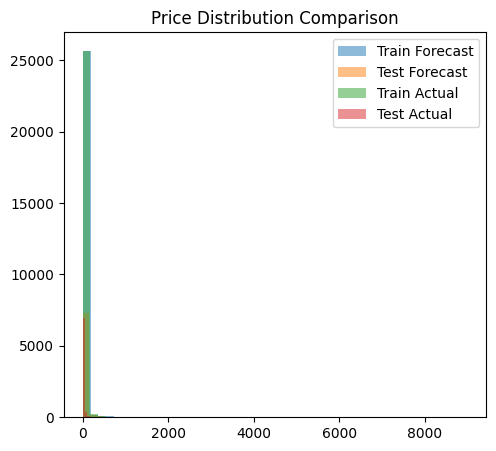

In [10]:
# plot distribution comparisons across train and test sets for prices
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(train_forecast_day["prices"], bins=50, alpha=0.5, label="Train Forecast")
plt.hist(test_forecast_day["prices"], bins=50, alpha=0.5, label="Test Forecast")
plt.hist(train_actual_day["prices"], bins=50, alpha=0.5, label="Train Actual")
plt.hist(test_actual_day["prices"], bins=50, alpha=0.5, label="Test Actual")
plt.legend()
plt.title("Price Distribution Comparison")

In [11]:
# Convert the whole dataset into a list of DayInputs
rng = np.random.default_rng(0)
days = [] # hold DayInputs for each day
for i in range(len(train_forecast_day)//24): # loop i over each day chunk

    forecast_prices, forecast_demand = train_forecast_day["prices"][i*24:(i+1)*24].values, train_forecast_day["consumption"][i*24:(i+1)*24].values
    actual_prices, actual_demand = train_actual_day["prices"][i*24:(i+1)*24].values, train_actual_day["consumption"][i*24:(i+1)*24].values

    days.append(DayInputs(
        prices_buy=actual_prices.tolist(),
        demand_MW=actual_demand.tolist(),
        prices_sell=actual_prices.tolist(),
        allow_export=True,
        dt_hours=1.0,
        prices_buy_forecast=forecast_prices.tolist(),
        demand_MW_forecast=forecast_demand.tolist(),
        prices_sell_forecast=forecast_prices.tolist(),
    ))

In [12]:
train_days = days
train_days

[DayInputs(prices_buy=[11.27, 10.04, 9.58, 9.95, 10.22, 10.79, 13.42, 14.31, 14.43, 14.63, 14.22, 13.52, 12.65, 11.94, 11.6, 10.74, 12.08, 15.91, 16.3, 15.11, 14.08, 12.72, 13.53, 15.19], demand_MW=[36824.115099, 36531.366488, 36072.16502, 35836.161867, 35998.542722, 36487.035645, 37099.051655, 37448.435337, 37988.181062, 39005.532595, 40011.210673, 40405.057113, 40320.725177, 39905.447776, 39384.852861, 39038.271821, 39255.080489, 40736.82994, 41737.743128, 41273.480684, 40551.189171, 39382.303166, 37563.3057, 35603.631407], prices_sell=[11.27, 10.04, 9.58, 9.95, 10.22, 10.79, 13.42, 14.31, 14.43, 14.63, 14.22, 13.52, 12.65, 11.94, 11.6, 10.74, 12.08, 15.91, 16.3, 15.11, 14.08, 12.72, 13.53, 15.19], allow_export=True, dt_hours=1.0, prices_buy_forecast=[14.13965834620507, 15.18909469847299, 14.619687500000024, 14.097931034482803, 16.79253521126757, 16.138881011292394, 25.07988763984128, 20.259191216960623, 19.947494722081313, 19.316208157620796, 17.585121888628237, 14.070192878980244, 

In [13]:
# convert test day into DayInputs
test_days = []
for i in range(len(test_actual_day)//24):

    forecast_prices, forecast_demand = test_forecast_day["prices"][i*24:(i+1)*24].values, test_forecast_day["consumption"][i*24:(i+1)*24].values
    actual_prices, actual_demand = test_actual_day["prices"][i*24:(i+1)*24].values, test_actual_day["consumption"][i*24:(i+1)*24].values

    test_days.append(DayInputs(
        prices_buy=actual_prices.tolist(),
        demand_MW=actual_demand.tolist(),
        prices_sell=actual_prices.tolist(),
        allow_export=True,
        dt_hours=1.0,
        prices_buy_forecast=forecast_prices.tolist(),
        demand_MW_forecast=forecast_demand.tolist(),
        prices_sell_forecast=forecast_prices.tolist(),
    ))

test_days

[DayInputs(prices_buy=[10.36, 9.85, 8.58, 8.16, 8.31, 8.55, 13.73, 14.27, 14.95, 14.81, 16.95, 17.4, 16.93, 17.61, 18.91, 16.62, 24.4, 32.71, 23.64, 18.16, 15.95, 16.65, 13.38, 8.94], demand_MW=[35609.173887, 35012.298856, 34369.582295, 34000.730337, 33865.078669, 34067.631206, 34581.277597, 35096.246776, 35734.404528, 36439.845839, 36744.05012, 37129.346639, 37712.230001, 37983.334375, 38646.237692, 39378.862698, 39596.636896, 40241.542928, 41594.989976, 41207.74756, 40723.690532, 39941.492043, 38748.035819, 37239.666045], prices_sell=[10.36, 9.85, 8.58, 8.16, 8.31, 8.55, 13.73, 14.27, 14.95, 14.81, 16.95, 17.4, 16.93, 17.61, 18.91, 16.62, 24.4, 32.71, 23.64, 18.16, 15.95, 16.65, 13.38, 8.94], allow_export=True, dt_hours=1.0, prices_buy_forecast=[19.951019009931297, 18.68025476645048, 17.54304078903866, 18.825166769348392, 14.64783533954283, 23.236254260907995, 24.48953765191922, 22.69729510984884, 31.335312500000047, 38.09000000000009, 19.4722328623757, 29.530920398009837, 21.6114814

In [14]:


# train_days = days[:-1]
# test_day = days[-1]

# solve request for evaluation
eval_requests =[]
for test_day in test_days:
    eval_requests.append(SolveRequest(battery=battery, day=test_day, solver="RL", solver_opts={"lambda_smooth": 0.00}))


In [15]:
# PPO training hyperparameters
settings = PPOTrainSettings(
    num_env_runners=4, # working on 4 cores, 4 cores left for otherd
    rollout_fragment_length=24, # 1 full day per episode
    gamma=0.99, 
    lr=1e-3,
    # lr = 3e-4,
    train_batch_size=24*64,
    # train_batch_size=24*128,
    # minibatch_size=24*8,
    minibatch_size=24*24,
    num_epochs=5,                 # bump to 10 if stable
    # num_epochs=10,                 
    clip_param=0.2,
    vf_clip_param=10.0,
    evaluation_interval=2,
    evaluation_episodes=20,
)

ckpt = train_rllib(
    eval_requests[0], days,
    settings = settings,
    num_iterations=200,
    obs_mode="forecast", obs_window=24,
    save_dir=f"runs_one_year_{REGION}_{YEAR}_1/rllib_battery"
)

:job_id:01000000
:actor_name:RolloutWorker


:job_id:01000000
:actor_name:RolloutWorker


:actor_name:RolloutWorker
:actor_name:RolloutWorker


:actor_name:RolloutWorker
:actor_name:RolloutWorker


:actor_name:RolloutWorker


:actor_name:RolloutWorker
2026-04-12 22:54:59,466	WARNING util.py:61 -- Install gputil for GPU system monitoring.


TensorBoard logdir: runs_one_year_Ercot_2023_1/rllib_battery/PPO_battery
[ITER   1] trainR=-9.54 (EMA=-9.54)  evalR=NA  KL=0.010✅  Entropy=1.420  Vexp=-0.000⚠
        notes: Value net weak → adjust value loss coeff or lr
[TRAIN] ep#   24  R= -31.948 len=24
[TRAIN] ep#   24  R=   8.256 len=24
[TRAIN] ep#   24  R=   1.399 len=24
[TRAIN] ep#   24  R=  64.630 len=24
[ITER   2] trainR=3.43 (EMA=-8.24)  evalR=NA  KL=0.017✅  Entropy=1.419  Vexp=-0.006⚠
        notes: Value net weak → adjust value loss coeff or lr
[TRAIN] ep#   48  R=  93.685 len=24
[TRAIN] ep#   48  R= -15.271 len=24
[TRAIN] ep#   48  R=  16.360 len=24
[TRAIN] ep#   48  R=  31.485 len=24
[ITER   3] trainR=20.95 (EMA=-5.32)  evalR=NA  KL=0.016✅  Entropy=1.424  Vexp=0.005⚠
        notes: Value net weak → adjust value loss coeff or lr
[TRAIN] ep#   24  R=  85.604 len=24
[ITER   4] trainR=36.21 (EMA=-1.17)  evalR=NA  KL=0.021⚠  Entropy=1.421  Vexp=0.010⚠
        notes: Value net weak → adjust value loss coeff or lr
[TRAIN] ep#   

In [16]:
ckpt = f"runs_one_year_{REGION}_{YEAR}_1/rllib_battery"

In [17]:
# eval_req = SolveRequest(battery=battery, day=test_days[0], solver="RL", solver_opts={"lambda_smooth": 0.00})
results = []
for eval_req in eval_requests:
    results.append(rollout_day(ckpt, eval_req, obs_mode="forecast", obs_window=24))

2026-04-12 22:58:38,761	WARNING util.py:61 -- Install gputil for GPU system monitoring.


Rollout done. Episode return (scaled): 92.914 | Cost: -693.292


2026-04-12 22:58:41,412	WARNING util.py:61 -- Install gputil for GPU system monitoring.


Rollout done. Episode return (scaled): 80.573 | Cost: -666.281


2026-04-12 22:58:44,357	WARNING util.py:61 -- Install gputil for GPU system monitoring.


...

Rollout done. Episode return (scaled): 134.257 | Cost: -1115.272


2026-04-12 23:13:47,288	WARNING util.py:61 -- Install gputil for GPU system monitoring.


Rollout done. Episode return (scaled): 105.978 | Cost: -813.840


2026-04-12 23:13:50,046	WARNING util.py:61 -- Install gputil for GPU system monitoring.


Rollout done. Episode return (scaled): 75.633 | Cost: -527.044


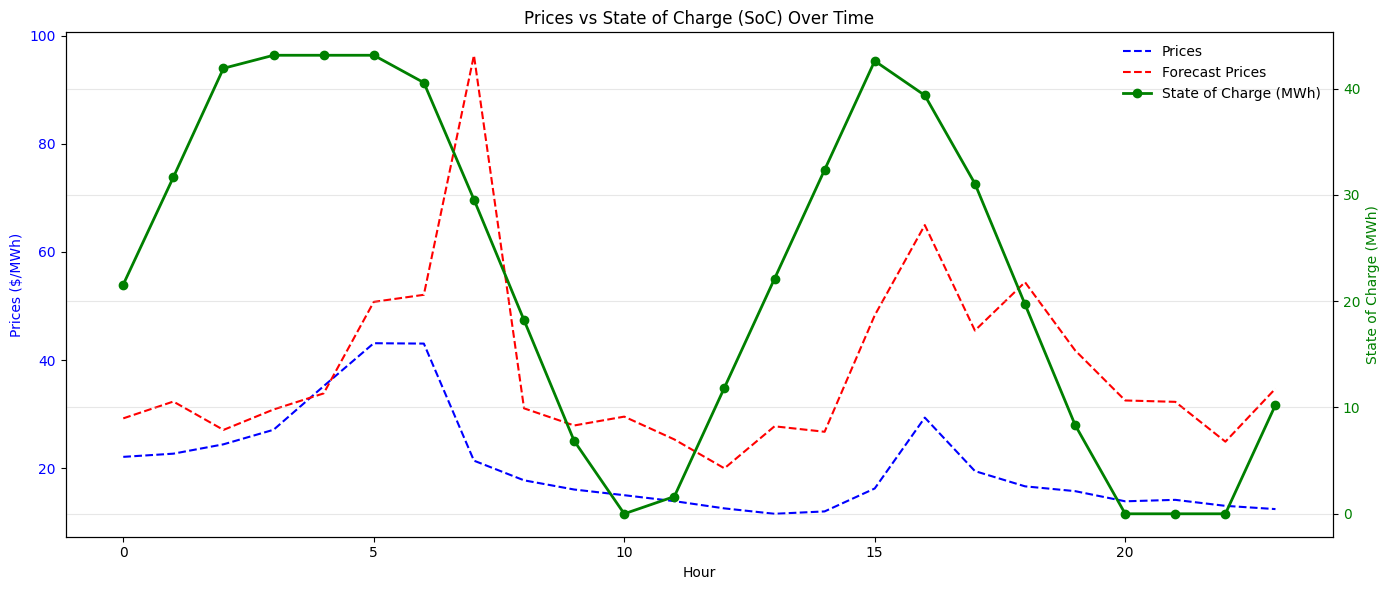

In [18]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.arange(24)
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Primary axis (Prices) ---
ax1.plot(hours, eval_req.day.prices_buy, '--b', label='Prices')
ax1.plot(hours, eval_req.day.prices_buy_forecast, '--r', label='Forecast Prices')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Prices ($/MWh)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# --- Secondary axis (State of Charge) ---
ax2 = ax1.twinx()
ax2.plot(hours, np.array(results[-1].soc[:-1]) * battery.capacity_MWh,
         '-og', label='State of Charge (MWh)', linewidth=2, markersize=6)
ax2.set_ylabel('State of Charge (MWh)', color='g')
ax2.tick_params(axis='y', labelcolor='g')


# --- Legends ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best', frameon=False)

plt.title('Prices vs State of Charge (SoC) Over Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
# import numpy as np
# import matplotlib.pyplot as plt

# hours = np.arange(24)

# # Data arrays
# load = np.array(eval_req.day.demand_kw)
# charge = np.array(res.charge_kw)
# discharge = np.array(res.discharge_kw)
# import_kw = np.array(res.import_kw)
# export_kw = np.array(res.export_kw) if getattr(eval_req.day, "allow_export", False) else np.zeros_like(load)

# # Flip battery convention for visualization
# charge_vis = -charge       # show charge below 0
# discharge_vis = discharge  # show discharge above 0

# # ---------------------- PLOT ----------------------
# fig, ax = plt.subplots(figsize=(14, 6))

# # --- positive side stacking (Import + Discharge + Export) ---
# # import is base layer
# ax.bar(hours, import_kw, width=0.5, color='orange', label='Import (+)')
# # discharge stacked on top of import
# ax.bar(hours, discharge_vis, width=0.5, bottom=import_kw, color='indianred', label='Discharge (+)')
# # export stacked on top (for clear separation)
# ax.bar(hours, export_kw, width=0.5, bottom=import_kw + discharge_vis, color='limegreen', alpha=0.7, label='Export (+)')

# # --- negative side stacking (Charge only) ---
# ax.bar(hours, charge_vis, width=0.5, color='cornflowerblue', label='Charge (−)')

# # --- Load as line ---
# ax.plot(hours, load, '-ok', linewidth=2, markersize=5, label='Load (kW)')

# # Formatting
# ax.axhline(0, color='black', linewidth=0.8)
# ax.set_ylabel("Power (kW)")
# ax.set_xlabel("Hour")
# ax.set_title("Power Balance Components (Charge ↓  |  Discharge ↑)")
# ax.legend(ncol=3, loc='upper left', fontsize=9)
# ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.show()


In [20]:
results[0]

SolveResponse(status='rllib_policy', message=None, objective_cost=-693.2924194335938, charge_MW=[10.711158752441406, 10.782500267028809, 1.2063407897949219, 1.13473674900888e-11, 1.13473674900888e-11, 8.485656621814996e-12, 5.039857420285898e-13, 2.582378755278114e-12, 0.0, 0.0, 1.7861121892929077, 1.4272948503494263, 4.55978536605835, 1.13473674900888e-11, 1.13473674900888e-11, 1.084998757505673e-11, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.021923065185547, 5.056797981262207], discharge_MW=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.671623945236206, 5.343682289123535, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 9.808157920837402, 10.782500267028809, 10.782500267028809, 9.600341796875, 9.666933920016163e-12, 4.928502050915995e-12, 0.0, 0.0], import_MW=[10.711158752441406, 10.782500267028809, 1.2063407897949219, 1.13473674900888e-11, 1.13473674900888e-11, 8.485656621814996e-12, 5.039857420285898e-13, 2.582378755278114e-12, 0.0, 0.0, 1.7861121892929077, 1.4272948503494263, 4.55978536605835, 1.13473674900888e-11

In [21]:
total_objective_value = 0
for day_result in results:
    total_objective_value += day_result.objective_cost
print(f"Total Objective Value over all days: ${total_objective_value:.2f} for {len(results)} days")

Total Objective Value over all days: $-763422.79 for 314 days


In [22]:
from typing import Sequence, Optional
def cost_from_soc(
    soc: Sequence[float],
    prices_buy: Sequence[float],
    demand_MW: Sequence[float],
    *,
    battery: BatteryParams,
    prices_sell: Optional[Sequence[float]] = None,
    allow_export: bool = False,
    dt_hours: float = 1.0,
):
    soc = np.asarray(soc, dtype=float)
    assert len(soc) >= 2, "SOC must include at least t=0 and t=1"
    T = len(soc) - 1

    prices_buy  = np.asarray(prices_buy, dtype=float)
    demand_MW   = np.asarray(demand_MW, dtype=float)
    assert len(prices_buy) == T and len(demand_MW) == T

    if prices_sell is None:
        prices_sell = prices_buy
    prices_sell = np.asarray(prices_sell, dtype=float)
    assert len(prices_sell) == T

    # Per-step energy change in MWh
    dE = (soc[1:] - soc[:-1]) * battery.capacity_MWh

    # Recover charge/discharge MW from SOC deltas and efficiencies
    charge_MW    = np.maximum(dE, 0.0) / (battery.eta_c * dt_hours)
    discharge_MW = np.maximum(-dE, 0.0) * (battery.eta_d / dt_hours)

    # Enforce hardware limits
    charge_MW    = np.minimum(charge_MW,    battery.cmax_MW)
    discharge_MW = np.minimum(discharge_MW, battery.dmax_MW)

    # Grid net load
    net = demand_MW + charge_MW - discharge_MW
    imp = np.maximum(net, 0.0)
    exp = np.maximum(-net, 0.0) if allow_export else np.zeros_like(net)

    # Cost (buy imports, optionally credit exports)
    cost = float(np.sum(prices_buy * imp * dt_hours) - np.sum(prices_sell * exp * dt_hours))

    out = {
        "charge_MW": charge_MW,
        "discharge_MW": discharge_MW,
        "import_MW": imp,
        "export_MW": exp,
        "net_MW": net,
        "objective_cost": cost,
    }
    return out

outputs =[]
for day_result, eval_req in zip(results,eval_requests):
    outputs.append(cost_from_soc(
        soc = day_result.soc,
        prices_buy=eval_req.day.prices_buy,
        demand_MW=eval_req.day.demand_MW,
        battery=battery,
        prices_sell=eval_req.day.prices_sell,
        allow_export=True,
        dt_hours=1
    ))

# out = cost_from_soc(
#     soc = res.soc,
#     prices_buy=eval_req.day.prices_buy,
#     demand_MW=eval_req.day.demand_MW,
#     battery=battery,
#     prices_sell=eval_req.day.prices_sell,
#     allow_export=True,
#     dt_hours=1
# )
# out["objective_cost"]

In [23]:
# out["export_MW"]

In [24]:
results[0]

SolveResponse(status='rllib_policy', message=None, objective_cost=-693.2924194335938, charge_MW=[10.711158752441406, 10.782500267028809, 1.2063407897949219, 1.13473674900888e-11, 1.13473674900888e-11, 8.485656621814996e-12, 5.039857420285898e-13, 2.582378755278114e-12, 0.0, 0.0, 1.7861121892929077, 1.4272948503494263, 4.55978536605835, 1.13473674900888e-11, 1.13473674900888e-11, 1.084998757505673e-11, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.021923065185547, 5.056797981262207], discharge_MW=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.671623945236206, 5.343682289123535, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 9.808157920837402, 10.782500267028809, 10.782500267028809, 9.600341796875, 9.666933920016163e-12, 4.928502050915995e-12, 0.0, 0.0], import_MW=[10.711158752441406, 10.782500267028809, 1.2063407897949219, 1.13473674900888e-11, 1.13473674900888e-11, 8.485656621814996e-12, 5.039857420285898e-13, 2.582378755278114e-12, 0.0, 0.0, 1.7861121892929077, 1.4272948503494263, 4.55978536605835, 1.13473674900888e-11

In [25]:
eval_requests[0]

SolveRequest(battery=BatteryParams(capacity_MWh=43.13, soc_init=0.5, soc_min=0.0, soc_max=1.0, cmax_MW=10.7825, dmax_MW=10.7825, eta_c=0.95, eta_d=0.95, soc_target=0.5), day=DayInputs(prices_buy=[10.36, 9.85, 8.58, 8.16, 8.31, 8.55, 13.73, 14.27, 14.95, 14.81, 16.95, 17.4, 16.93, 17.61, 18.91, 16.62, 24.4, 32.71, 23.64, 18.16, 15.95, 16.65, 13.38, 8.94], demand_MW=[35609.173887, 35012.298856, 34369.582295, 34000.730337, 33865.078669, 34067.631206, 34581.277597, 35096.246776, 35734.404528, 36439.845839, 36744.05012, 37129.346639, 37712.230001, 37983.334375, 38646.237692, 39378.862698, 39596.636896, 40241.542928, 41594.989976, 41207.74756, 40723.690532, 39941.492043, 38748.035819, 37239.666045], prices_sell=[10.36, 9.85, 8.58, 8.16, 8.31, 8.55, 13.73, 14.27, 14.95, 14.81, 16.95, 17.4, 16.93, 17.61, 18.91, 16.62, 24.4, 32.71, 23.64, 18.16, 15.95, 16.65, 13.38, 8.94], allow_export=True, dt_hours=1.0, prices_buy_forecast=[19.951019009931297, 18.68025476645048, 17.54304078903866, 18.82516676

In [26]:
outputs[0]

{'charge_MW': array([10.71115822, 10.7825    ,  1.20634124,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.78611264,  1.42729571,  4.55978502,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  2.02192316,  5.05679811]),
 'discharge_MW': array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  1.67162499,  5.34368203,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  9.80815836, 10.78249916, 10.7825    ,  9.60034209,
         0.        ,  0.        ,  0.        ,  0.        ]),
 'import_MW': array([35619.88504522, 35023.081356  , 34370.78863624, 34000.730337  ,
        33865.078669  , 34067.631206  , 34581.277597  , 35096.246776  ,
        35732.73290301, 36434.50215697, 36745.83623264, 37130.77393471,
        37716.78978602, 37983.3343

In [27]:
# help me create a dataframe to csv to store the results from eval_requests and outputs 
# I wannt to store each row as an hour of a day so explode the day and store each hour in a single row and stack all the days together to form the dataframe.
import pandas as pd
eval_data = {
    "prices_actual": [],
    "prices_forecast": [],
    "actual_demand": [],
    "forecast_demand": [],
    "soc": [],  # exclude final SOC which is after last action
    "charge_MW": [],
    "discharge_MW": [],
    "import_MW": [],
    "export_MW": [],
}

for eval_req, output, result in zip(eval_requests, outputs, results):
    eval_data["prices_actual"]+= list(eval_req.day.prices_buy)
    eval_data["prices_forecast"]+= list(eval_req.day.prices_buy_forecast)
    eval_data["actual_demand"]+= list(eval_req.day.demand_MW)
    eval_data["forecast_demand"]+= list(eval_req.day.demand_MW_forecast)
    eval_data["soc"]+= list(result.soc[:-1])
    eval_data["charge_MW"]+= output["charge_MW"].tolist()
    eval_data["discharge_MW"]+= output["discharge_MW"].tolist()
    eval_data["import_MW"]+= output["import_MW"].tolist()
    eval_data["export_MW"]+= output["export_MW"].tolist()
eval_df = pd.DataFrame(eval_data)
eval_df.head()

,prices_actual,prices_forecast,actual_demand,forecast_demand,soc,charge_MW,discharge_MW,import_MW,export_MW
0,10.36,19.951019,35609.173887,34845.987813,0.500000,10.711158,0.0,35619.885045,0.0
1,9.85,18.680255,35012.298856,33644.664955,0.735929,10.782500,0.0,35023.081356,0.0
2,8.58,17.543041,34369.582295,35174.204402,0.973429,1.206341,0.0,34370.788636,0.0
3,8.16,18.825167,34000.730337,35310.228599,1.000000,0.000000,0.0,34000.730337,0.0
4,8.31,14.647835,33865.078669,34971.241890,1.000000,0.000000,0.0,33865.078669,0.0


In [28]:
eval_df.shape, len(eval_requests)*24

((7536, 9), 7536)

In [29]:
eval_df["profit_step"] = (eval_df["discharge_MW"] - eval_df["charge_MW"]) * eval_df["prices_actual"] * 1
total_profit = eval_df["profit_step"].sum()

print("Total arbitrage profit:", total_profit)

Total arbitrage profit: 763422.7570685942


In [30]:
eval_df.to_csv(f"rlPPO_{data_version}_{forecast_type}_one_year_{REGION}_{YEAR}_1.csv", index = False)

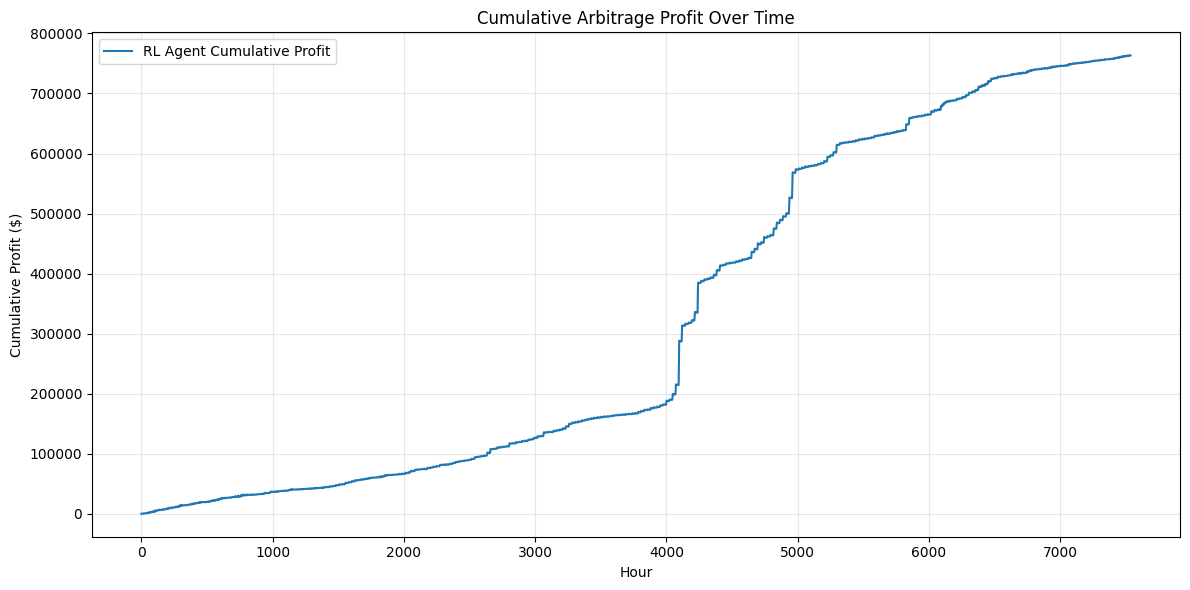

In [31]:
# now I want to have a cumulative profit plot of the profit step over time, so I can see how the profit accumulates over the course of the year. I also want to compare it to a baseline strategy, such as a simple heuristic that charges when prices are below a certain threshold and discharges when prices are above a certain threshold. This will help me visualize the performance of the RL agent compared to a simple rule-based strategy.
import matplotlib.pyplot as plt
eval_df["cumulative_profit"] = eval_df["profit_step"].cumsum()
plt.figure(figsize=(12,6))
plt.plot(eval_df["cumulative_profit"], label="RL Agent Cumulative Profit")
plt.xlabel("Hour")
plt.ylabel("Cumulative Profit ($)")
plt.title("Cumulative Arbitrage Profit Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()